# 02 · IndicTrans2: Assamese & Manipuri (zero-shot → fine-tune → evaluate)

Baseline track. We take **IndicTrans2** (AI4Bharat) which already supports Assamese (`asm_Beng`) and Meiteilon/Manipuri (`mni_Beng`) and:

1. measure **zero-shot** quality on our held-out test sets (both directions),
2. **fine-tune** on our `data_clean/` train splits,
3. **evaluate** before vs. after with chrF++ / spBLEU **and analytic views** (per-length-bucket
   scores, best/worst examples).

## 0 · Environment check

In [ ]:
import importlib, subprocess, sys
REQ = ["torch","transformers","datasets","accelerate","sacrebleu","sentencepiece",
       "sacremoses","IndicTransToolkit","matplotlib","pandas","numpy"]
missing = [m for m in REQ if importlib.util.find_spec(m) is None]
if missing:
    print("installing missing:", missing)
    subprocess.run([sys.executable,"-m","pip","install","--no-input",*missing], check=True)
else:
    print("all libraries present")

import torch, transformers
print("torch", torch.__version__, "| transformers", transformers.__version__)
print("CUDA:", torch.cuda.is_available(), "| GPUs:", torch.cuda.device_count(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

all libraries present
torch 2.8.0+cu128 | transformers 4.45.2
CUDA: True | GPUs: 3 | NVIDIA RTX A6000


/data/sujay/miniconda3/envs/wmt_2026_indic/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### HF access check
Confirms the token can actually pull the gated repos before we spend time elsewhere.

In [ ]:
from huggingface_hub import whoami, hf_hub_download
try:
    print("HF account:", whoami().get("name"))
except Exception as e:
    print("Not logged in:", e)

GATED = ["ai4bharat/indictrans2-en-indic-dist-200M","ai4bharat/indictrans2-indic-en-dist-200M"]
for r in GATED:
    try:
        hf_hub_download(r, "config.json"); print("access OK :", r)
    except Exception as e:
        print("NO ACCESS:", r, "->", str(e).splitlines()[0][:70])
        print("   Fix: visit https://huggingface.co/%s and click 'Agree and access repository'." % r)

HF account: sujayrittikar
access OK : ai4bharat/indictrans2-en-indic-dist-200M
access OK : ai4bharat/indictrans2-indic-en-dist-200M


## 1 · Config

In [ ]:
import os
from dataclasses import dataclass, field

@dataclass
class CFG:
    # ----- the big switch -----
    SMOKE_TEST: bool = False         # False = FULL data (real baseline). True = tiny dry-run only.

    # ----- what to run -----
    langs: dict = field(default_factory=lambda: {"Assamese": "asm_Beng",
                                                  "Manipuri": "mni_Beng"})
    directions: tuple = ("en2indic", "indic2en")     # both ways
    model_size: str = "dist-200M"    # "dist-200M" (fast) or "1B" (best; also needs repo access)

    # ----- paths -----
    data_dir: str = "data_clean"
    out_dir:  str = "runs/indictrans2"

    # ----- inference / eval -----
    gpu: int = 0                     # which CUDA device to use
    eval_beams: int = 5
    max_len: int = 256
    infer_batch: int = 32

    # ----- fine-tuning -----
    epochs: float = 10.0
    lr: float = 3e-5
    train_batch: int = 32
    grad_accum: int = 1
    warmup_ratio: float = 0.05
    weight_decay: float = 0.01
    fp16: bool = True

    def __post_init__(self):
        if self.SMOKE_TEST:                 # tiny end-to-end check ONLY (not a real baseline)
            self.epochs = 1.0
            self.eval_sample = 120          # cap test rows scored
            self.train_cap   = 1500         # cap train rows per (lang,direction)
            self.dev_cap     = 200
        else:
            self.eval_sample = None         # FULL test set, both languages
            self.train_cap   = None         # FULL train set, both languages
            self.dev_cap     = None         # FULL dev set

cfg = CFG()
DEVICE = f"cuda:{cfg.gpu}" if __import__("torch").cuda.is_available() else "cpu"
MODELS = {
    "en2indic": f"ai4bharat/indictrans2-en-indic-{cfg.model_size}",
    "indic2en": f"ai4bharat/indictrans2-indic-en-{cfg.model_size}",
}
os.makedirs(cfg.out_dir, exist_ok=True)
print("SMOKE_TEST =", cfg.SMOKE_TEST, "| device =", DEVICE)
print("models:", MODELS)

SMOKE_TEST = False | device = cuda:0
models: {'en2indic': 'ai4bharat/indictrans2-en-indic-dist-200M', 'indic2en': 'ai4bharat/indictrans2-indic-en-dist-200M'}


## 2 · Load cleaned data

In [ ]:
import pandas as pd, numpy as np
def load_split(lang, split):
    p = os.path.join(cfg.data_dir, lang, f"{split}.tsv")
    return pd.read_csv(p, sep="\t").dropna()

DATA = {lg: {sp: load_split(lg, sp) for sp in ["train","dev","test"]} for lg in cfg.langs}
rows = [{"lang": lg, **{sp: len(DATA[lg][sp]) for sp in ["train","dev","test"]}} for lg in cfg.langs]
display(pd.DataFrame(rows).set_index("lang"))
print("\nSample (Assamese):")
display(DATA["Assamese"]["test"].head(3))

,train,dev,test
lang,,,
Assamese,45129,1987,2000
Manipuri,20539,1143,1144



Sample (Assamese):


,en,tgt
0,Jaipur mirrors Delhi scenes as 3000040000 migr...,জয়পুৰে দিল্লীৰ দৃশ্যবোৰ প্ৰতিফলিত কৰে যেতিয়া...
1,"Speak unto the children of Israel , saying , Y...","তুমি ইস্ৰায়েলৰ সন্তানসকলক কোৱা , তোমালোকে গৰু..."
2,"Genesis 3 1 6 Furthermore , through the centur...",আদিপুস্তক ৩ ১ ৬ ইয়াৰ উপৰিও যুগ যুগ ধৰি ঈশ্বৰক...


## 3 · Model loading & translation helper
`en2indic`: source=English (`eng_Latn`); `indic2en`: target=English. The **source** is wrapped with
language tags via `IndicProcessor`; outputs are post-processed back to the proper script.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from IndicTransToolkit.processor import IndicProcessor

IP = IndicProcessor(inference=True)
_CACHE = {}
def get_model(direction):
    if direction not in _CACHE:
        name = MODELS[direction]
        tok = AutoTokenizer.from_pretrained(name, trust_remote_code=True)
        mdl = AutoModelForSeq2SeqLM.from_pretrained(name, trust_remote_code=True).to(DEVICE).eval()
        _CACHE[direction] = (tok, mdl)
        print(f"loaded {name}  ({sum(p.numel() for p in mdl.parameters())/1e6:.0f}M params)")
    return _CACHE[direction]

@torch.no_grad()
def translate(texts, src_lang, tgt_lang, direction, model=None, bs=None, beams=None):
    tok, mdl = get_model(direction)
    if model is not None: mdl = model           # use a fine-tuned model if supplied
    bs = bs or cfg.infer_batch; beams = beams or cfg.eval_beams
    out = []
    for i in range(0, len(texts), bs):
        chunk = list(texts[i:i+bs])
        batch = IP.preprocess_batch(chunk, src_lang=src_lang, tgt_lang=tgt_lang)
        enc = tok(batch, truncation=True, padding="longest", max_length=cfg.max_len,
                  return_tensors="pt").to(mdl.device)
        gen = mdl.generate(**enc, num_beams=beams, max_length=cfg.max_len, num_return_sequences=1)
        dec = tok.batch_decode(gen, skip_special_tokens=True)
        out.extend(IP.postprocess_batch(dec, lang=tgt_lang))
    return out

# the (source_col, ref_col, src_lang, tgt_lang, target_is_indic) recipe per (lang, direction)
def recipe(lang, direction):
    code_ = cfg.langs[lang]
    if direction == "en2indic":
        return "en", "tgt", "eng_Latn", code_, True
    else:
        return "tgt", "en", code_, "eng_Latn", False

## 4 · Scoring (chrF++ primary, spBLEU secondary)
chrF++ is script-agnostic and robust on small/morphologically-rich test sets. spBLEU uses the
FLORES-200 tokenizer for Indic targets; English targets use standard `13a` tokenization.

In [ ]:
import sacrebleu
_CHRF = sacrebleu.CHRF(word_order=2)   # chrF++

def make_bleu(target_is_indic):
    try:
        return sacrebleu.BLEU(tokenize="flores200") if target_is_indic else sacrebleu.BLEU(tokenize="13a")
    except Exception:
        return sacrebleu.BLEU()        # fallback if flores200 tokenizer unavailable

def score_corpus(hyps, refs, target_is_indic):
    bleu = make_bleu(target_is_indic)
    return {"chrF++": round(_CHRF.corpus_score(hyps, [refs]).score, 2),
            "spBLEU" if target_is_indic else "BLEU": round(bleu.corpus_score(hyps, [refs]).score, 2)}

def sent_chrf(hyp, ref):
    return sacrebleu.sentence_chrf(hyp, [ref]).score

def evaluate(lang, direction, model=None, split="test", n=None):
    src_c, ref_c, sl, tl, is_indic = recipe(lang, direction)
    df = DATA[lang][split]
    if n: df = df.head(n)
    hyps = translate(df[src_c].tolist(), sl, tl, direction, model=model)
    refs = df[ref_c].tolist()
    out = df[[src_c, ref_c]].copy(); out.columns = ["source","reference"]
    out["hypothesis"] = hyps
    out["sent_chrf"] = [round(sent_chrf(h, r), 1) for h, r in zip(hyps, refs)]
    return score_corpus(hyps, refs, is_indic), out

## 5 · Zero-shot baseline

In [ ]:
zs_scores, zs_outputs = {}, {}
for lg in cfg.langs:
    for d in cfg.directions:
        sc, out = evaluate(lg, d, n=cfg.eval_sample)
        key = f"{lg}/{d}"
        zs_scores[key] = sc; zs_outputs[key] = out
        print(f"{key:24s} {sc}")

zs_table = pd.DataFrame(zs_scores).T
zs_table.index.name = "lang/direction"
display(zs_table)

loaded ai4bharat/indictrans2-en-indic-dist-200M  (212M params)
Assamese/en2indic        {'chrF++': 31.19, 'spBLEU': 13.94}
loaded ai4bharat/indictrans2-indic-en-dist-200M  (212M params)
Assamese/indic2en        {'chrF++': 41.07, 'BLEU': 19.11}
Manipuri/en2indic        {'chrF++': 41.7, 'spBLEU': 25.05}
Manipuri/indic2en        {'chrF++': 57.16, 'BLEU': 31.89}


,chrF++,spBLEU,BLEU
lang/direction,,,
Assamese/en2indic,31.19,13.94,NaN
Assamese/indic2en,41.07,NaN,19.11
Manipuri/en2indic,41.70,25.05,NaN
Manipuri/indic2en,57.16,NaN,31.89


### 5a · Analytic view: scores & length sensitivity

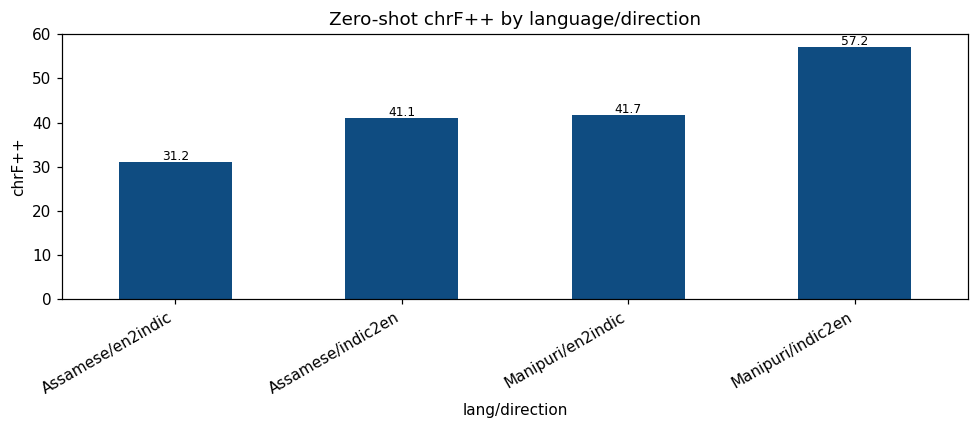

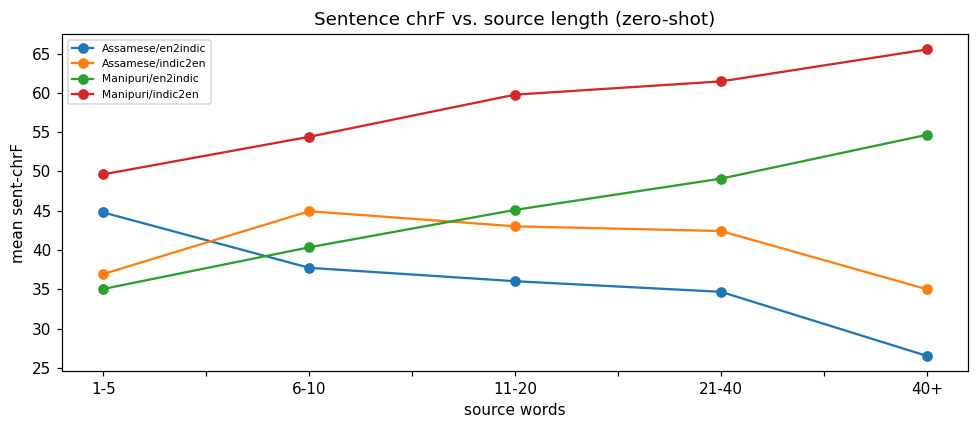

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"]=110

# (i) chrF++ bar per lang/direction
fig, ax = plt.subplots(figsize=(9,4))
zs_table["chrF++"].plot(kind="bar", ax=ax, color="#0f4c81")
ax.set_title("Zero-shot chrF++ by language/direction"); ax.set_ylabel("chrF++"); plt.xticks(rotation=30, ha="right")
for i,v in enumerate(zs_table["chrF++"]): ax.text(i, v+0.4, f"{v:.1f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

# (ii) chrF++ vs source length bucket (does quality fall on long sentences?)
def length_curve(out_df):
    d = out_df.copy(); d["src_words"] = d["source"].str.split().map(len)
    bins=[0,5,10,20,40,1000]; labels=["1-5","6-10","11-20","21-40","40+"]
    d["bucket"]=pd.cut(d["src_words"], bins=bins, labels=labels)
    return d.groupby("bucket", observed=True)["sent_chrf"].mean()

fig, ax = plt.subplots(figsize=(9,4))
for key, out in zs_outputs.items():
    length_curve(out).plot(marker="o", ax=ax, label=key)
ax.set_title("Sentence chrF vs. source length (zero-shot)"); ax.set_xlabel("source words"); ax.set_ylabel("mean sent-chrF")
ax.legend(fontsize=7); plt.tight_layout(); plt.show()

### 5b · Eyeball best  and worst translations

In [ ]:
def show_examples(out_df, k=3):
    s = out_df.sort_values("sent_chrf")
    print("---- WORST ----")
    for _,r in s.head(k).iterrows():
        print(f"[{r.sent_chrf:.0f}] SRC: {r.source[:90]}\n      REF: {r.reference[:90]}\n      HYP: {r.hypothesis[:90]}\n")
    print("---- BEST ----")
    for _,r in s.tail(k).iterrows():
        print(f"[{r.sent_chrf:.0f}] SRC: {r.source[:90]}\n      REF: {r.reference[:90]}\n      HYP: {r.hypothesis[:90]}\n")

ex_key = f"Assamese/en2indic"
print("Examples for", ex_key, "\n"); show_examples(zs_outputs[ex_key])

Examples for Assamese/en2indic 

---- WORST ----
[0] SRC: Protestant preacher Jonathan Edwards used to strike fear in the hearts of 18th - century C
      REF: ৩৩ : ২১-২৫ ; ৩৪ : ১ , ২ ; গীত.
      HYP: প্ৰটেষ্টাণ্ট প্ৰচাৰক জনাথন এডৱাৰ্ডে 18 শতিকাৰ ঔপনিৱেশিক আমেৰিকানসকলৰ হৃদয়ত নৰকৰ চিত্ৰাত্ম

[4] SRC: That was like “ iron ” instead of “ stones ” or “ gold ” instead of “ copper . ”
      REF: ( লূক ২ : ৪১ ; দ্বিতী.
      HYP: সেইটো "তাম" ৰ পৰিৱৰ্তে "শিল" বা "সোণ" ৰ পৰিৱৰ্তে "লোহা" ৰ দৰে আছিল।

[5] SRC: And I seek not mine own glory there is one that seeketh and judgeth .
      REF: মই আপোনালোকক সচাঁকৈয়ে কওঁ , কোনোৱে যদি মোৰ বাক্য পালন কৰে , তেওঁ কোনো কালে মৃত্যুক নেদেখি
      HYP: আৰু মই মোৰ নিজৰ গৌৰৱ বিচৰা নাই, আৰু বিচাৰি বিচাৰি বিচাৰি বিচাৰি বিচাৰি বিচাৰি বিচাৰি বিচাৰ

---- BEST ----
[96] SRC: Kejriwals ministers complaint led to Modi govt action against top Delhi civil servants .
      REF: কেজৰিৱালৰ মন্ত্ৰীসকলৰ অভিযোগৰ ফলত মোডী চৰকাৰে দিল্লীৰ শীৰ্ষ অসামৰিক কৰ্মচাৰীসকলৰ বিৰুদ্ধে 
  

## 6 · Fine-tuning
We fine-tune **one model per direction** on the **combined** Assamese+Manipuri train data (IndicTrans2
is multilingual, sharing helps the smaller language). Source is tagged via `IndicProcessor`; labels
are the target text tokenized with `text_target` (no language tags).

In [ ]:
from datasets import Dataset, concatenate_datasets
from transformers import (Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq)

def build_dataset(direction, split, cap=None):
    tok, _ = get_model(direction)
    parts = []
    for lg in cfg.langs:
        src_c, ref_c, sl, tl, _ = recipe(lg, direction)
        df = DATA[lg][split]
        if cap: df = df.head(cap)
        psrc = IP.preprocess_batch(df[src_c].tolist(), src_lang=sl, tgt_lang=tl)
        enc  = tok(psrc, truncation=True, max_length=cfg.max_len)
        lab  = tok(text_target=df[ref_c].tolist(), truncation=True, max_length=cfg.max_len)
        ds = Dataset.from_dict({"input_ids": enc["input_ids"],
                                "attention_mask": enc["attention_mask"],
                                "labels": lab["input_ids"]})
        parts.append(ds)
    return concatenate_datasets(parts).shuffle(seed=42)

def finetune(direction):
    tok, model = get_model(direction)
    train_ds = build_dataset(direction, "train", cfg.train_cap)
    dev_ds   = build_dataset(direction, "dev",   cfg.dev_cap)
    coll = DataCollatorForSeq2Seq(tok, model=model)
    out  = os.path.join(cfg.out_dir, direction)
    args = Seq2SeqTrainingArguments(
        output_dir=out, overwrite_output_dir=True,
        per_device_train_batch_size=cfg.train_batch, per_device_eval_batch_size=cfg.infer_batch,
        gradient_accumulation_steps=cfg.grad_accum, learning_rate=cfg.lr,
        num_train_epochs=cfg.epochs, warmup_ratio=cfg.warmup_ratio, weight_decay=cfg.weight_decay,
        fp16=cfg.fp16, eval_strategy="epoch", save_strategy="epoch",
        load_best_model_at_end=True, metric_for_best_model="eval_loss", greater_is_better=False,
        logging_steps=5 if cfg.SMOKE_TEST else 50, report_to=[], save_total_limit=1, predict_with_generate=False)
    trainer = Seq2SeqTrainer(model=model, args=args, train_dataset=train_ds,
                             eval_dataset=dev_ds, data_collator=coll, tokenizer=tok)
    print(f"\n=== fine-tuning {direction}  (train={len(train_ds):,} dev={len(dev_ds):,}) ===")
    trainer.train()
    return trainer

trainers = {d: finetune(d) for d in cfg.directions}


=== fine-tuning en2indic  (train=65,668 dev=3,130) ===


/data/sujay/miniconda3/envs/wmt_2026_indic/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,3.132600,2.924605
2,1.944600,1.763315
3,1.497600,1.355902
4,1.313600,1.185554
5,1.184700,1.091750
6,1.114000,1.036457
7,1.066600,1.004230
8,1.042600,0.980364
9,1.009600,0.968924
10,1.002000,0.964351


/data/sujay/miniconda3/envs/wmt_2026_indic/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/data/sujay/miniconda3/envs/wmt_2026_indic/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/data/sujay/miniconda3/envs/wmt_2026_indic/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/data/sujay/miniconda3/envs/wmt_2026_indic/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return


=== fine-tuning indic2en  (train=65,668 dev=3,130) ===


/data/sujay/miniconda3/envs/wmt_2026_indic/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,1.688600,1.571876
2,1.557800,1.519185
3,1.477100,1.497495
4,1.388900,1.486421
5,1.297400,1.486254
6,1.290000,1.485033
7,1.221200,1.487588
8,1.222500,1.487547
9,1.179500,1.489290
10,1.157300,1.491069


/data/sujay/miniconda3/envs/wmt_2026_indic/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/data/sujay/miniconda3/envs/wmt_2026_indic/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/data/sujay/miniconda3/envs/wmt_2026_indic/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/data/sujay/miniconda3/envs/wmt_2026_indic/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return

### 6a · Training curves

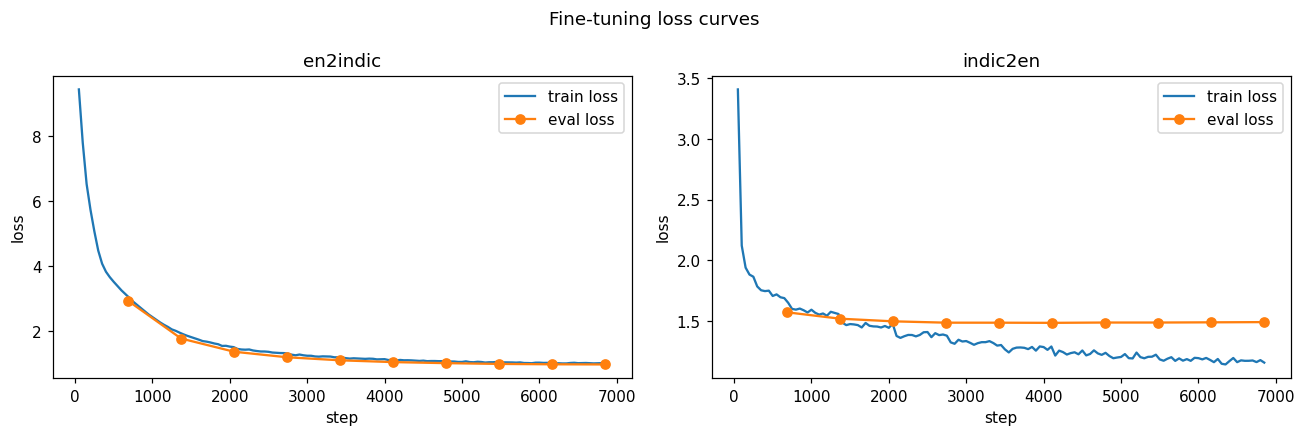

In [ ]:
fig, axes = plt.subplots(1, len(trainers), figsize=(6*len(trainers), 4), squeeze=False)
for ax, (d, tr) in zip(axes[0], trainers.items()):
    hist = pd.DataFrame(tr.state.log_history)
    if "loss" in hist:      ax.plot(hist.dropna(subset=["loss"])["step"], hist.dropna(subset=["loss"])["loss"], label="train loss")
    if "eval_loss" in hist: ax.plot(hist.dropna(subset=["eval_loss"])["step"], hist.dropna(subset=["eval_loss"])["eval_loss"], "o-", label="eval loss")
    ax.set_title(f"{d}"); ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.legend()
fig.suptitle("Fine-tuning loss curves"); plt.tight_layout(); plt.show()

## 7 · Evaluate fine-tuned models

In [ ]:
ft_scores, ft_outputs = {}, {}
for lg in cfg.langs:
    for d in cfg.directions:
        sc, out = evaluate(lg, d, model=trainers[d].model, n=cfg.eval_sample)
        key=f"{lg}/{d}"; ft_scores[key]=sc; ft_outputs[key]=out
        print(f"{key:24s} {sc}")

# combined before/after table
metric = "chrF++"
rows=[]
for key in zs_scores:
    z=zs_scores[key][metric]; f=ft_scores[key][metric]
    rows.append({"lang/direction":key, "zero-shot":z, "fine-tuned":f, "Δ":round(f-z,2)})
compare = pd.DataFrame(rows).set_index("lang/direction")
display(compare)

Assamese/en2indic        {'chrF++': 34.3, 'spBLEU': 16.63}
Assamese/indic2en        {'chrF++': 47.15, 'BLEU': 26.46}
Manipuri/en2indic        {'chrF++': 48.8, 'spBLEU': 36.75}
Manipuri/indic2en        {'chrF++': 63.6, 'BLEU': 41.0}


,zero-shot,fine-tuned,Δ
lang/direction,,,
Assamese/en2indic,31.19,34.30,3.11
Assamese/indic2en,41.07,47.15,6.08
Manipuri/en2indic,41.70,48.80,7.10
Manipuri/indic2en,57.16,63.60,6.44


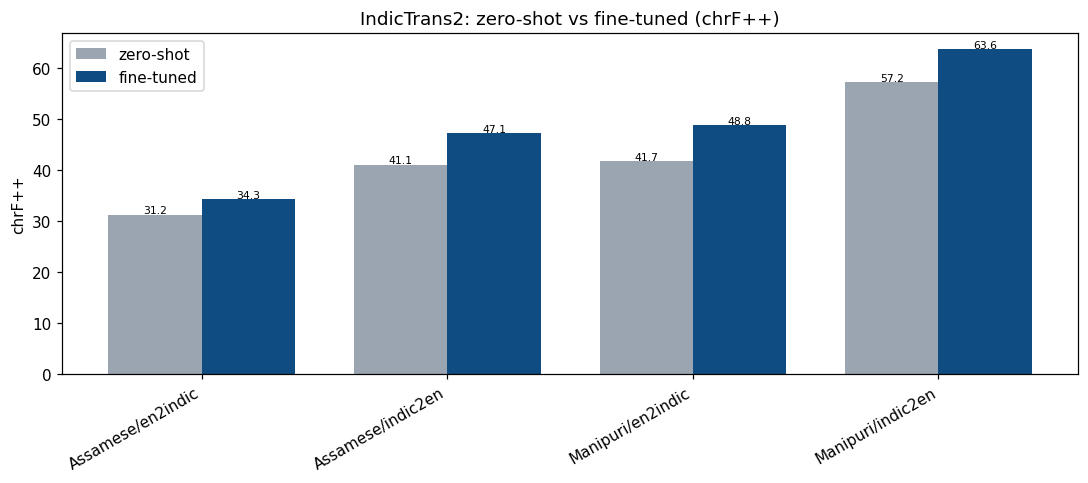

In [ ]:
# before/after bar
fig, ax = plt.subplots(figsize=(10,4.5))
x=np.arange(len(compare)); w=.38
ax.bar(x-w/2, compare["zero-shot"], w, label="zero-shot", color="#9aa5b1")
ax.bar(x+w/2, compare["fine-tuned"], w, label="fine-tuned", color="#0f4c81")
ax.set_xticks(x); ax.set_xticklabels(compare.index, rotation=30, ha="right"); ax.set_ylabel("chrF++")
ax.set_title("IndicTrans2: zero-shot vs fine-tuned (chrF++)"); ax.legend()
for i,(z,f) in enumerate(zip(compare["zero-shot"],compare["fine-tuned"])):
    ax.text(i-w/2,z+0.3,f"{z:.1f}",ha="center",fontsize=7); ax.text(i+w/2,f+0.3,f"{f:.1f}",ha="center",fontsize=7)
plt.tight_layout(); plt.show()

## 8 · Save models & results

In [ ]:
import json
for d, tr in trainers.items():
    save_to = os.path.join(cfg.out_dir, f"{d}-finetuned")
    tr.save_model(save_to); get_model(d)[0].save_pretrained(save_to)
    print("saved", save_to)

results = {"smoke_test": cfg.SMOKE_TEST, "model_size": cfg.model_size,
           "eval_sample": cfg.eval_sample,
           "zero_shot": zs_scores, "fine_tuned": ft_scores}
with open(os.path.join(cfg.out_dir, "results.json"), "w") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
compare.to_csv(os.path.join(cfg.out_dir, "compare_chrf.csv"))
print("\nwrote", os.path.join(cfg.out_dir, "results.json"), "+ compare_chrf.csv")

saved runs/indictrans2/en2indic-finetuned
saved runs/indictrans2/indic2en-finetuned

wrote runs/indictrans2/results.json + compare_chrf.csv
